# Netflix Dataset EDA

In [1]:
#importing libraries
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv('data/netflix_titles.csv')
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

From df.isnull().sum(), we can see that **director** has 2634 null values, **cast** has 825 null values, **country** has 831 null values, **date_added** has 10 null values, **rating** has 4 null values, and **duration** has 3 null values. This will be important to keep track of when trying to find insights on data. Since I will most likely be using groupby functions later on, I want to fix these null values to hold a value "Unavailable" so it won't affect later functions that I might use. 

In [8]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
#seperating director, cast, and country as they're non-critical to my questions

Since there is a relatively small amount of missing rating and duration entries, I'll choose to simply drop those rows

In [9]:
df = df.dropna(subset=['date_added', 'rating'])

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


I also want to change the formatting of **date_added** just to make it easier to work with later.

In [10]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

From here, I'll extract the year added and make a new dummy column that stores only the year of the date it was added to Netflix.

In [12]:
df['year_added'] = df['date_added'].dt.year

In [11]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
print(df.shape)
print(df.duplicated().sum())

(8807, 12)
0


We can see that there are 8807 Rows and 12 Columns.

## Question 1: Year Over Year Growth

In [13]:
yearly_growth = df.groupby('year_added').size()
yearly_growth

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     428
2017    1186
2018    1648
2019    2016
2020    1879
2021    1498
dtype: int64

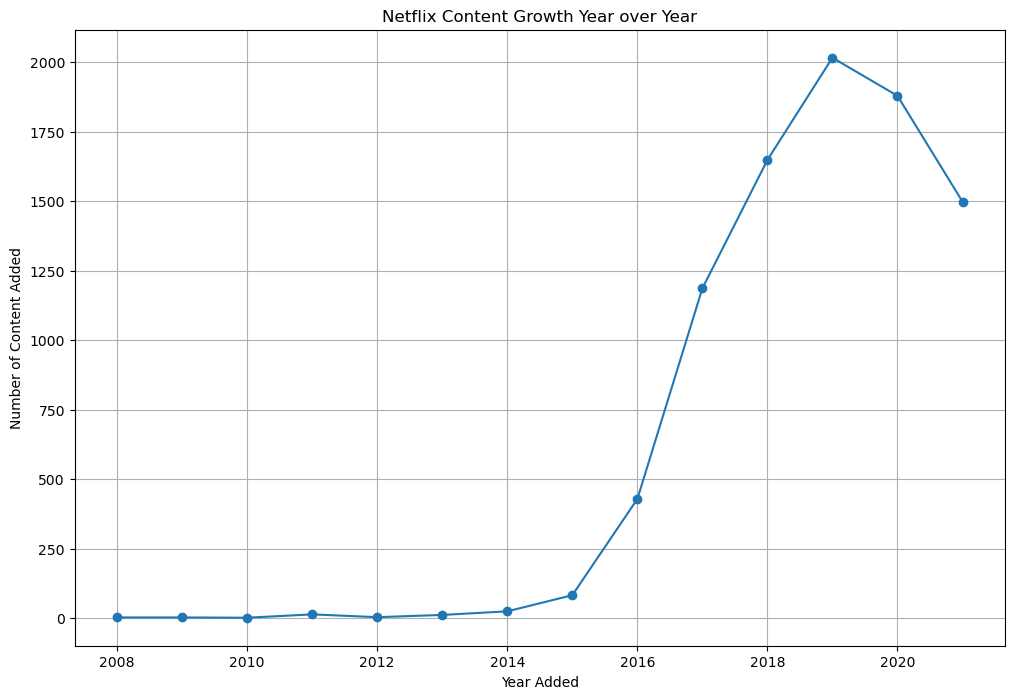

In [16]:
plt.figure(figsize=(12, 8))
yearly_growth.plot(kind='line', marker='o')
plt.title('Netflix Content Growth Year over Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Content Added')
plt.grid(True)
plt.show()

### Findings

As we can see from the chart above, as well as the numerical results, Netflix had a very small amount of content available in the beginning of 2008. The amount of content available year to year was under 50 from 2008 until 2015, where 84 options were available. From 2014 to 2015, it was a 4x in available content. From 2015 to 2016, another 3x in content, with the number being 428. From 2017 too 2019, there was growth by around 400 available contents, with the peak of offered content being 2016 in 2019. Afterwards, there was a slight drop off from 2019 to 2020, and another drop off from 2020 to 2021.

#### Context

After doing some research, I can see that Netflix first started thier Online Streaming Service in 2007 January (https://www.vdocipher.com/blog/history-of-neflix/). In 2016, they had a aggresive expansion, expanding to over 190 countries. This reflects the outcomes of the graph above, giving us understanding that our analysis is correct. As for the drop off in 2019 - 2021, I'm assuming that COVID-19 hit many filming crews and the ability to make more content was drastically reduced. Although further analysis would be needed in a different Netflix dataset since I can't really look into that witht this dataset and it's given values.